In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Data Loading and cleaning:

### i. Data Loading :

In [3]:
housing_data = pd.read_csv(filepath_or_buffer='Housing.csv')
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


### ii. Shape :

In [4]:
housing_data.shape

(545, 13)

### iii. Column Names :

In [5]:
housing_data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

### iv. Data Types :

In [6]:
housing_data.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

#### Here every column has valid data types 

### v. Checking Missing Values :

In [7]:
housing_data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### As we verifid , the given dataset does not contains any null values , Therefore it is easier to proceed .

### vi. Checking Duplicates :

In [8]:
housing_data.duplicated().sum()

np.int64(0)

#### The dataset also do not contains any duplicated values .

### vii. Describe :

In [9]:
housing_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 2. .Data Exploration :

### i. Outliers analysis :

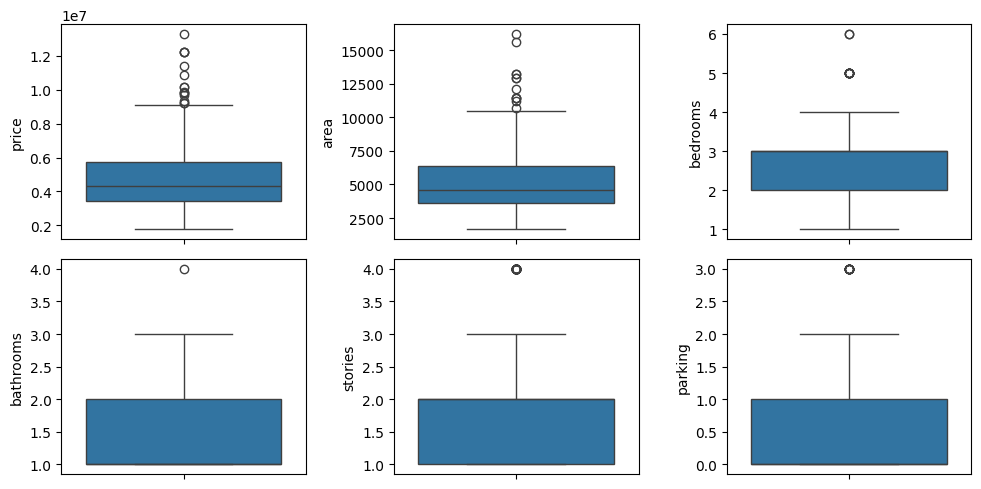

In [10]:
fig,axs = plt.subplots(2,3,figsize =(10,5))
plt1 = sns.boxplot(housing_data['price'] , ax = axs[0,0])
plt1 = sns.boxplot(housing_data['area'] , ax = axs[0,1])
plt1 = sns.boxplot(housing_data['bedrooms'] , ax = axs[0,2])
plt1 = sns.boxplot(housing_data['bathrooms'] , ax = axs[1,0])
plt1 = sns.boxplot(housing_data['stories'] , ax = axs[1,1])
plt1 = sns.boxplot(housing_data['parking'] , ax = axs[1,2])
plt.tight_layout()

#### * Outlier Treatment
#### * Price and area have considerable outliers.
#### * We can drop the outliers as we have sufficient data.

### i. Removing Outliers treatment for price :

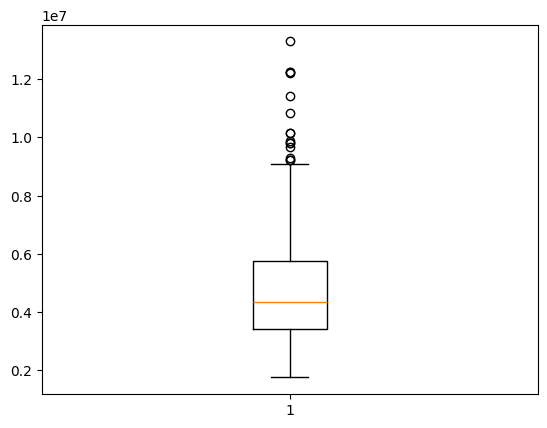

In [11]:
plt.boxplot(housing_data.price)
Q1 = housing_data.price.quantile(0.25)
Q3 = housing_data.price.quantile(0.75)
IQR = Q3 - Q1
lower_bound =  Q1 - 1.5*IQR
upper_bound =  Q3 + 1.5*IQR
housing_data= housing_data[(housing_data.price >= lower_bound) & (housing_data.price <= upper_bound )]

### ii. Removing Outliers treatment for area :

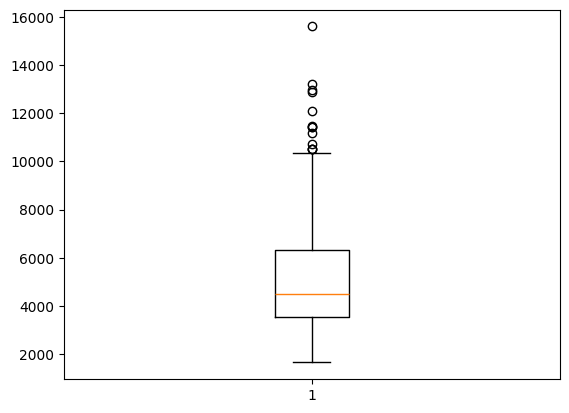

In [12]:
plt.boxplot(housing_data.area)
Q1 = housing_data.area.quantile(0.25)
Q3 = housing_data.area.quantile(0.75)
IQR = Q3 - Q1
housing_data = housing_data[(housing_data.area >= Q1 - 1.5*IQR) & (housing_data.area <= Q3 + 1.5*IQR)]

### iii. Reassuming outliers changes :

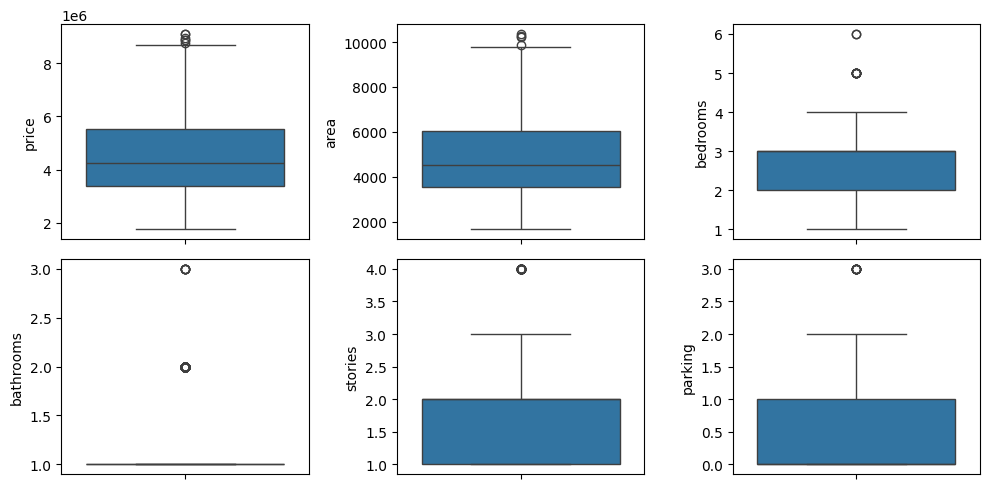

In [13]:
fig,axs = plt.subplots(2,3,figsize =(10,5))
plt1 = sns.boxplot(housing_data['price'] , ax = axs[0,0])
plt1 = sns.boxplot(housing_data['area'] , ax = axs[0,1])
plt1 = sns.boxplot(housing_data['bedrooms'] , ax = axs[0,2])
plt1 = sns.boxplot(housing_data['bathrooms'] , ax = axs[1,0])
plt1 = sns.boxplot(housing_data['stories'] , ax = axs[1,1])
plt1 = sns.boxplot(housing_data['parking'] , ax = axs[1,2])
plt.tight_layout()

#### Now , many of the outliers in the price and area column has been corrected

## 3. Exploratory Data Analytics :

### i. Visualising Numeric Variables :

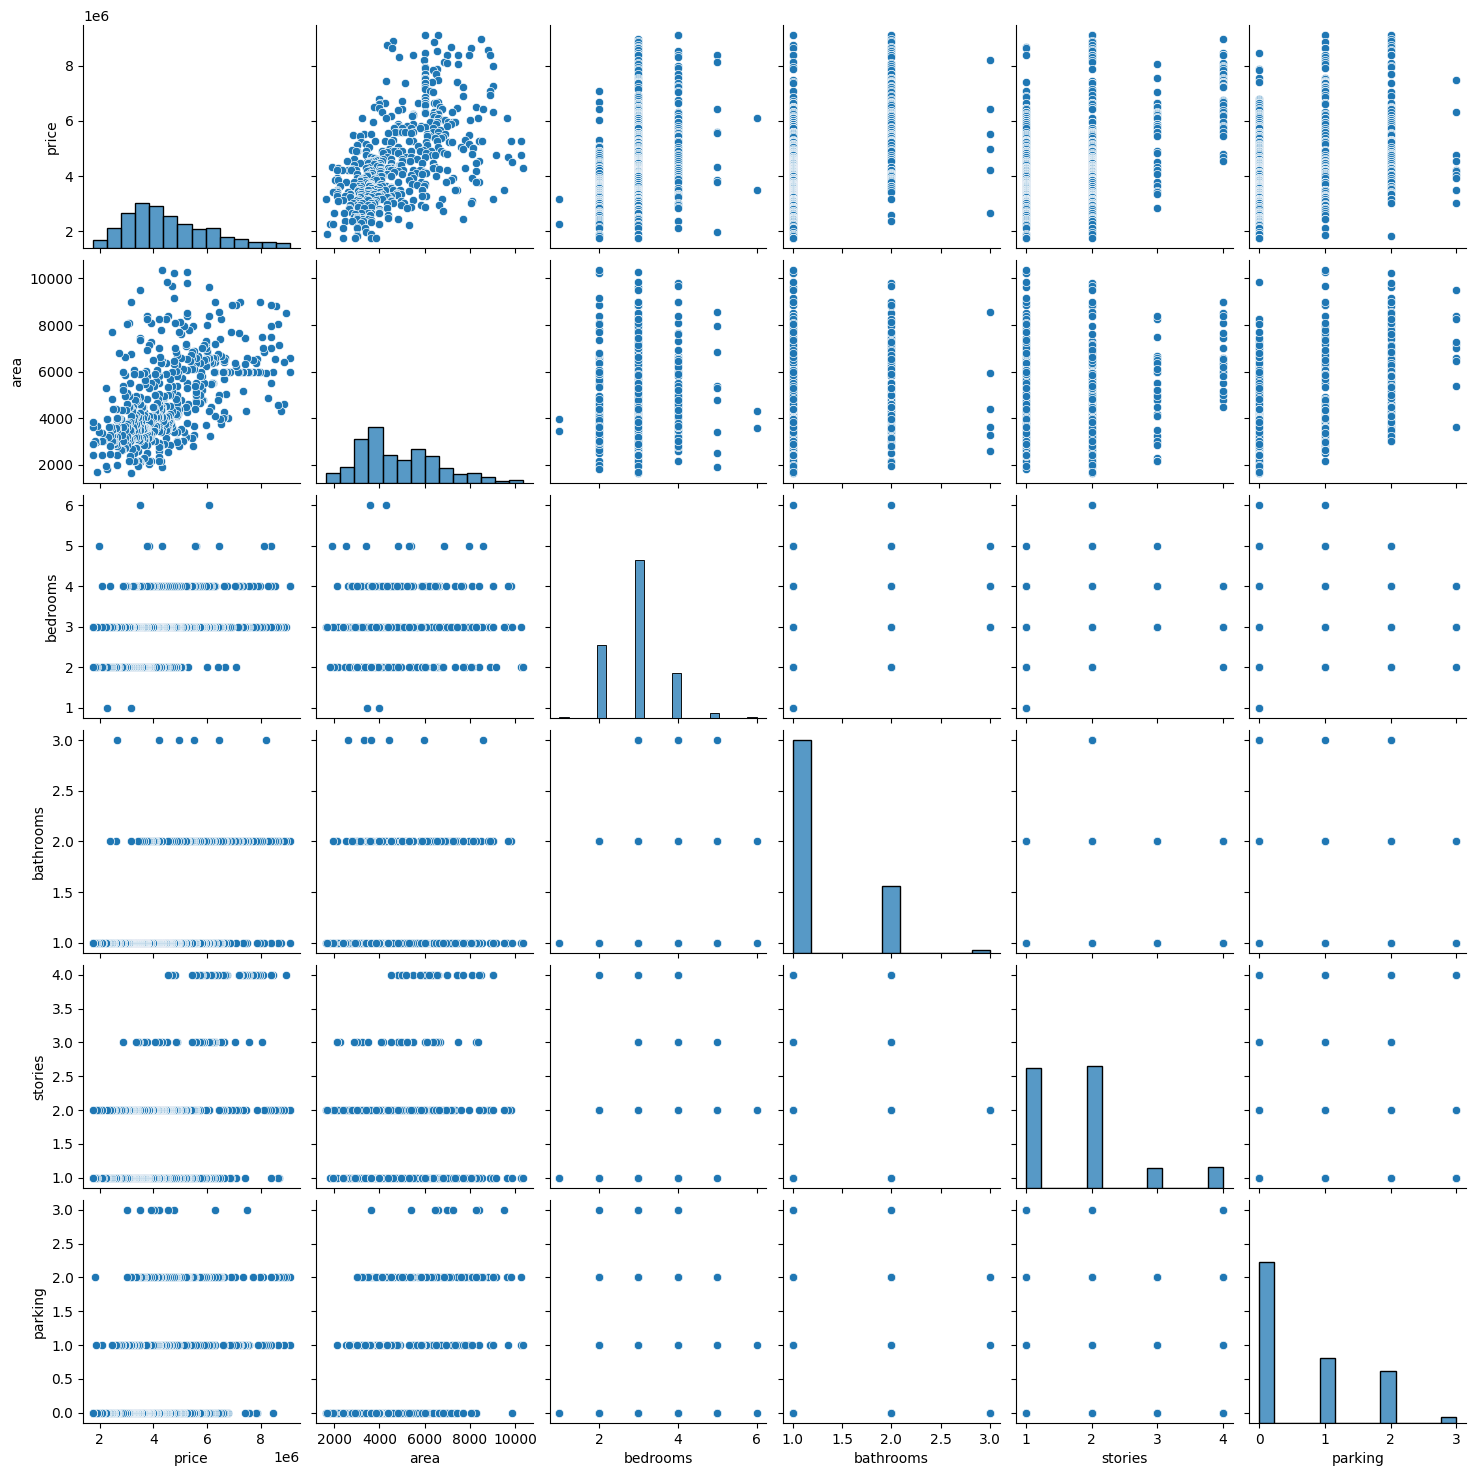

In [14]:
sns.pairplot(housing_data)
plt.show()

#### Visualising Categorical Variables
#### As you might have noticed, there are a few categorical variables as well. Let's make a boxplot for some of these variables.

### ii. BoxPlot for categorical values :

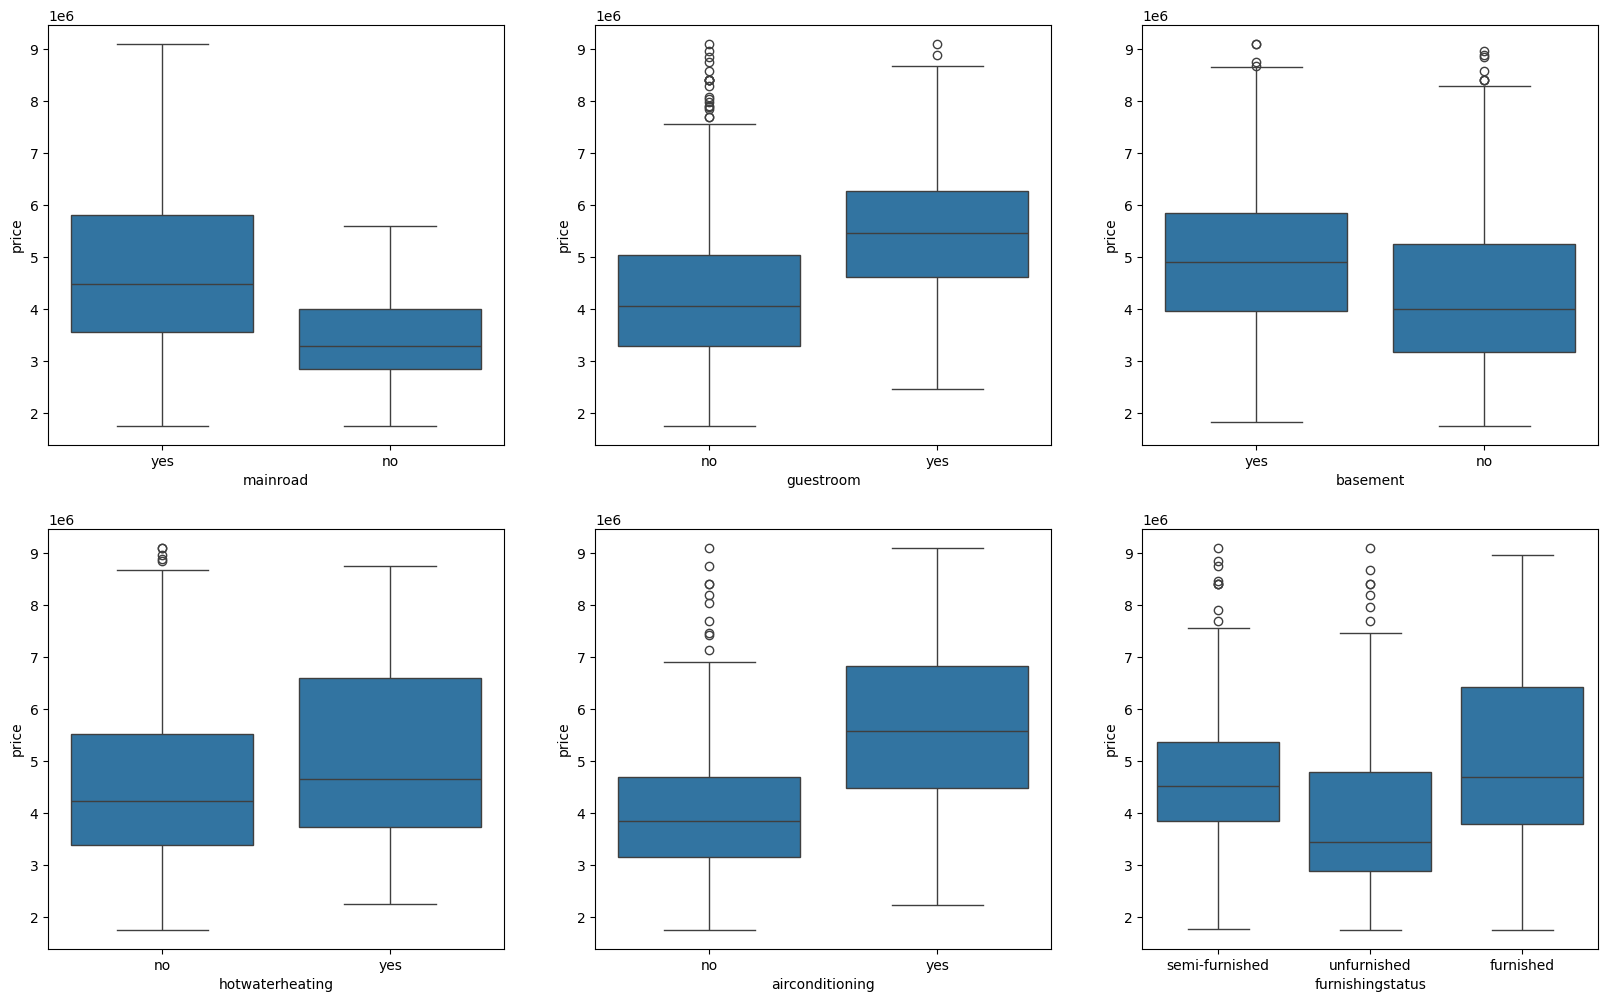

In [15]:
plt.figure(figsize=(20,12))

# for mainroad :
plt.subplot(2,3,1)
sns.boxplot(data = housing_data , x='mainroad' , y='price')

# for guestroom
plt.subplot(2,3,2)
sns.boxplot(data = housing_data , x = 'guestroom' , y='price')

# for basement
plt.subplot(2,3,3)
sns.boxplot(data = housing_data , x = 'basement' , y='price')

# for hotwaterheating
plt.subplot(2,3,4)
sns.boxplot(data = housing_data , x = 'hotwaterheating' , y='price')

# for airconditioning	
plt.subplot(2,3,5)
sns.boxplot(data = housing_data , x = 'airconditioning' , y='price')

# for furnishingstatus	
plt.subplot(2,3,6)
sns.boxplot(data = housing_data , x = 'furnishingstatus' , y='price')

plt.show()

#### We can also visualise some of these categorical features parallely by using the hue argument. Below is the plot for furnishingstatus with airconditioning as the hue.

<Axes: xlabel='furnishingstatus', ylabel='price'>

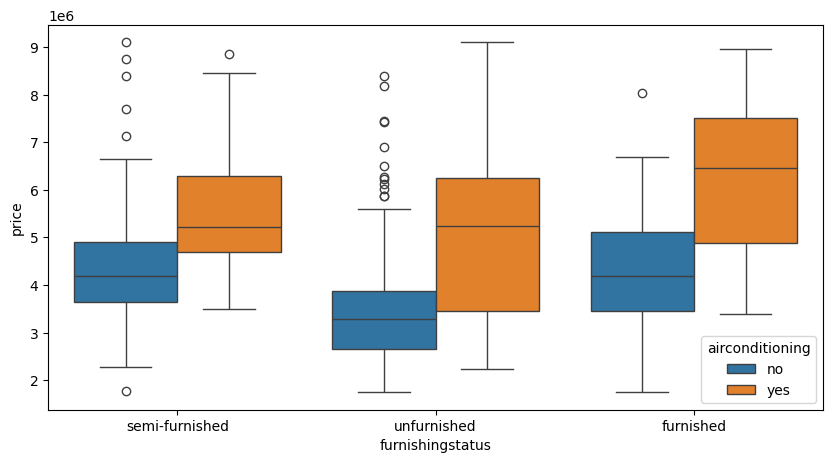

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(x = 'furnishingstatus' , y= 'price' , hue = 'airconditioning',data = housing_data)

#### As we can now conclude that the price of the increases with airconditioning present .

## 4. Data Preparation :

### i. Binary conversion :

* You can see that your dataset has many columns with values as 'Yes' or 'No'.
* But in order to fit a regression line, we would need numerical values and not string. Hence, we need to convert them to 1s and 0s, where 1 is a 'Yes' and 0 is a 'No'.

In [17]:
bin_list = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']

def binary_map(x):
    return x.map(
        {"yes" : 1,
         "no" : 0}
    )
housing_data[bin_list] = housing_data[bin_list].apply(binary_map)    

In [18]:
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished


#### Now you can see tht the categorical datas are now converted to binary which will be easier for regression .

### ii. Dummy variables :

* The variable furnishingstatus has three levels. We need to convert these levels into integer as well.
* For this, we will use something called dummy variables.

In [26]:
furnishing_status = pd.get_dummies(housing_data['furnishingstatus'])
furnishing_status = furnishing_status.astype(int)
furnishing_status.head()

,furnished,semi-furnished,unfurnished
15,0,1,0
16,0,0,1
17,1,0,0
18,1,0,0
19,0,1,0


Now, you don't need three columns. You can drop the furnished column, as the type of furnishing can be identified with just the last two columns where 

* 00 will correspond to furnished
* 01 will correspond to unfurnished
* 10 will correspond to semi-furnished

In [30]:
furnishing_status_final = pd.get_dummies(housing_data['furnishingstatus'], drop_first=True)
furnishing_status_final = furnishing_status_final.astype(int)
furnishing_status_final

,semi-furnished,unfurnished
15,1,0
16,0,1
17,0,0
18,0,0
19,1,0
...,...,...
540,0,1
541,1,0
542,0,1
543,0,0


In [45]:
housing_data_bin = pd.concat([housing_data,furnishing_status_final],axis= 1)
housing_data_bin.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished,1,0
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished,0,1
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished,0,0
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished,0,0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished,1,0


### iii. Drop 'furnishingstatus' as we have created the dummies for it :

In [52]:
housing_final = housing_data_bin.copy()
housing_final.head()
housing_final.drop(['furnishingstatus'],axis= 1, inplace=True)
housing_final

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1,0
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0,1
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,0,0
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,0,0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


## 5. Splitting the Data into Training and Testing Sets

### i. Training and Testing Sets :

In [56]:
from sklearn.model_selection import train_test_split

np.random.seed(0)
df_train, df_test = train_test_split(
    housing_final,
    train_size=0.7,
    test_size=0.3,
    random_state=100
)

### ii. Rescaling the Features :

#### As you saw in the demonstration for Simple Linear Regression, scaling doesn't impact your model. Here we can see that except for area, all the columns have small integer values. So it is extremely important to rescale the variables so that they have a comparable scale. If we don't have comparable scales, then some of the coefficients as obtained by fitting the regression model might be very large or very small as compared to the other coefficients. This might become very annoying at the time of model evaluation. So it is advised to use standardization or normalization so that the units of the coefficients obtained are all on the same scale. As you know, there are two common ways of rescaling

### Min-Max scaling :

In [59]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

min_max_data = ['area' , 'bedrooms', 'bathrooms', 'stories', 'parking','price' ]

df_train[min_max_data] = scaler.fit_transform(df_train[min_max_data])
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
148,0.523810,0.526907,0.4,0.0,0.666667,1,0,0,0,0,0.000000,1,1,0
236,0.390476,0.114134,0.2,0.0,0.333333,1,1,1,0,0,0.000000,1,1,0
356,0.275238,0.072738,0.8,0.5,0.000000,0,0,1,0,1,0.333333,0,0,0
425,0.219048,0.151390,0.2,0.0,0.000000,1,0,1,0,0,0.666667,0,0,0
516,0.095238,0.157895,0.2,0.0,0.000000,0,1,0,0,0,0.333333,0,0,1


In [61]:
df_train.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
count,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000,361.000000
mean,0.383701,0.350081,0.390582,0.127424,0.268698,0.875346,0.168975,0.349030,0.038781,0.313019,0.218837,0.207756,0.476454,0.304709
std,0.209712,0.207184,0.149146,0.224465,0.287833,0.330784,0.375250,0.477325,0.193341,0.464366,0.287286,0.406264,0.500138,0.460923
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.237143,0.189829,0.200000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.338095,0.295092,0.400000,0.000000,0.333333,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.514286,0.491425,0.400000,0.000000,0.333333,1.000000,0.000000,1.000000,0.000000,1.000000,0.333333,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Let's check the correlation coefficients to see which variables are highly correlated

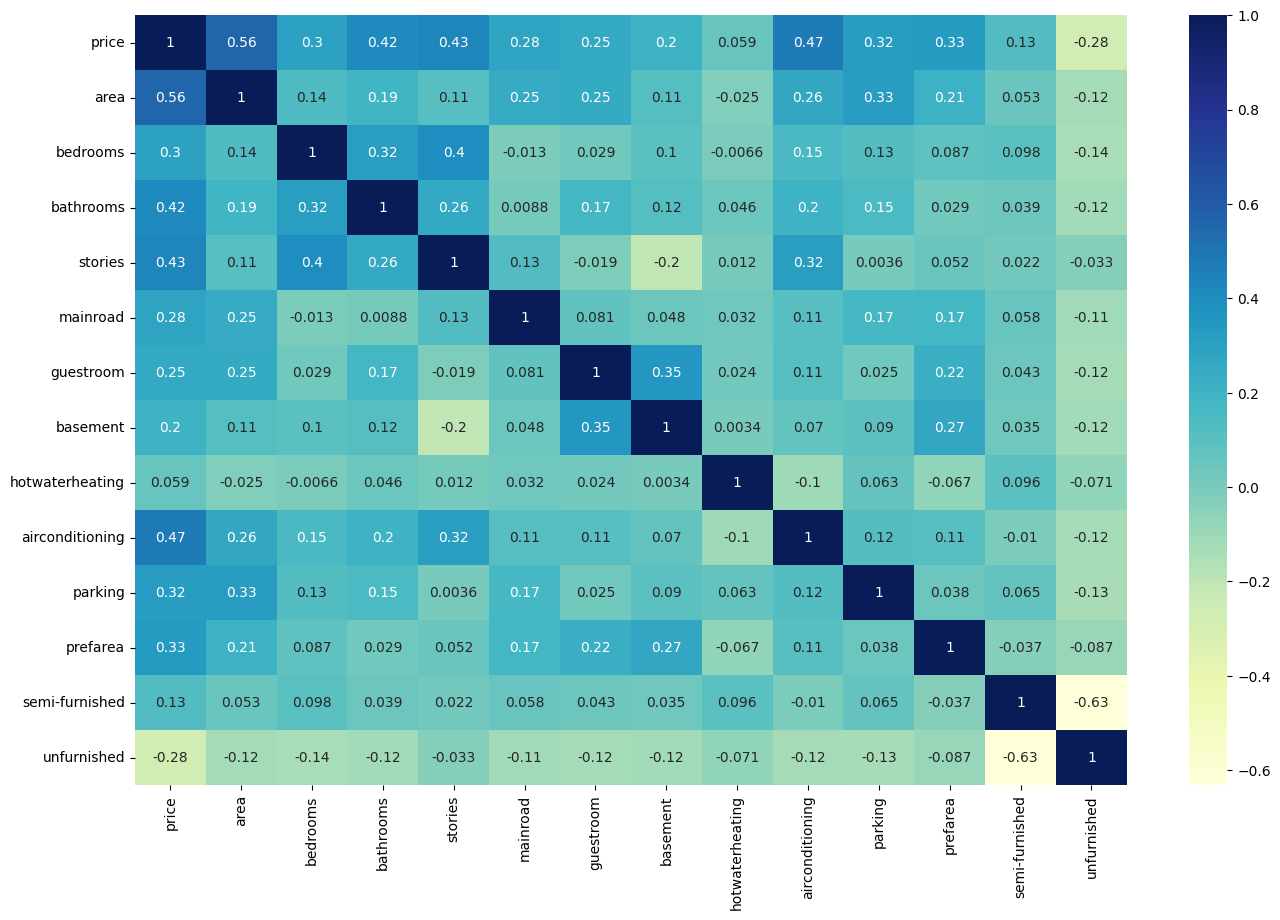

In [62]:
plt.figure(figsize = (16, 10))
sns.heatmap(df_train.corr(), annot = True, cmap="YlGnBu")
plt.show()

### As you might have noticed, area seems to the correlated to price the most. Let's see a pairplot for area vs price.

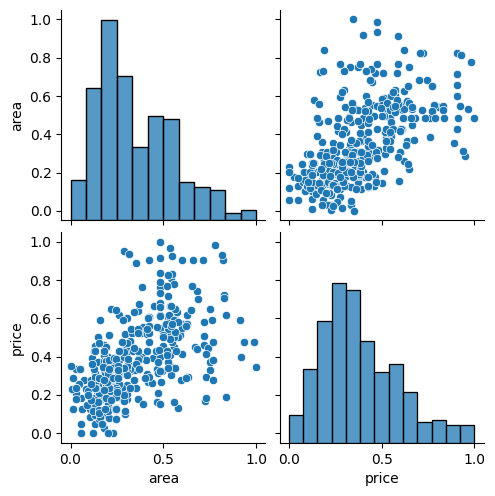

In [63]:
sns.pairplot(data = df_train,vars = ['area','price'])

#### Dividing into X and Y sets for the model building

In [64]:
x_train = df_train
y_train =df_train.pop('price')

## 6. Model Building :

#### This time, we will be using the LinearRegression function from SciKit Learn for its compatibility with RFE 

In [70]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [72]:
lm = LinearRegression()
lm.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
rfe = RFE(estimator= lm,n_features_to_select= 6)             
rfe = rfe.fit(x_train, y_train)

In [76]:
list(zip(x_train.columns,rfe.support_,rfe.ranking_))

[('area', np.True_, np.int64(1)),
 ('bedrooms', np.False_, np.int64(7)),
 ('bathrooms', np.True_, np.int64(1)),
 ('stories', np.True_, np.int64(1)),
 ('mainroad', np.False_, np.int64(5)),
 ('guestroom', np.False_, np.int64(6)),
 ('basement', np.False_, np.int64(4)),
 ('hotwaterheating', np.False_, np.int64(2)),
 ('airconditioning', np.True_, np.int64(1)),
 ('parking', np.True_, np.int64(1)),
 ('prefarea', np.True_, np.int64(1)),
 ('semi-furnished', np.False_, np.int64(8)),
 ('unfurnished', np.False_, np.int64(3))]

In [77]:
col = x_train.columns[rfe.support_]
col

Index(['area', 'bathrooms', 'stories', 'airconditioning', 'parking',
       'prefarea'],
      dtype='object')

In [79]:
x_train.columns[~rfe.support_] #not accepted ny rfe

Index(['bedrooms', 'mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'semi-furnished', 'unfurnished'],
      dtype='object')

### Building model using statsmodel, for the detailed statistics :

In [83]:
x_train_rfe = x_train[col]
x_train_rfe

,area,bathrooms,stories,airconditioning,parking,prefarea
148,0.526907,0.0,0.666667,0,0.000000,1
236,0.114134,0.0,0.333333,0,0.000000,1
356,0.072738,0.5,0.000000,1,0.333333,0
425,0.151390,0.0,0.000000,0,0.666667,0
516,0.157895,0.0,0.000000,0,0.333333,0
...,...,...,...,...,...,...
255,0.470727,0.0,0.000000,1,0.333333,0
307,0.257244,0.0,0.333333,0,0.666667,0
72,0.368421,0.0,1.000000,1,0.000000,1
377,0.111768,0.5,0.333333,0,0.000000,1


In [86]:
# Adding a constant variable 

import statsmodels.api as sm  
x_train_rfe = sm.add_constant(x_train_rfe)

In [88]:
x_train_rfe

,const,area,bathrooms,stories,airconditioning,parking,prefarea
148,1.0,0.526907,0.0,0.666667,0,0.000000,1
236,1.0,0.114134,0.0,0.333333,0,0.000000,1
356,1.0,0.072738,0.5,0.000000,1,0.333333,0
425,1.0,0.151390,0.0,0.000000,0,0.666667,0
516,1.0,0.157895,0.0,0.000000,0,0.333333,0
...,...,...,...,...,...,...,...
255,1.0,0.470727,0.0,0.000000,1,0.333333,0
307,1.0,0.257244,0.0,0.333333,0,0.666667,0
72,1.0,0.368421,0.0,1.000000,1,0.000000,1
377,1.0,0.111768,0.5,0.333333,0,0.000000,1


In [92]:
lm = sm.OLS(y_train,x_train_rfe).fit()

In [93]:
#Let's see the summary of our linear model

print(lm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     92.83
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           1.31e-69
Time:                        23:01:32   Log-Likelihood:                 222.77
No. Observations:                 361   AIC:                            -431.5
Df Residuals:                     354   BIC:                            -404.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.1097      0.015     

In [94]:
# Calculate the VIFs for the model

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [96]:
vif = pd.DataFrame()
x= x_train_rfe
vif['Features'] = x.columns
vif['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,4.51
1,area,1.24
4,airconditioning,1.20
3,stories,1.17
5,parking,1.14
2,bathrooms,1.12
6,prefarea,1.05


### Residual Analysis of the train data :

#### So, now to check if the error terms are also normally distributed (which is infact, one of the major assumptions of linear regression), let us plot the histogram of the error terms and see what it looks like.

In [98]:
y_train_price = lm.predict(x_train_rfe)
res = (y_train_price - y_train)

In [100]:
%matplotlib inline

C:\Users\91882\AppData\Local\Temp\ipykernel_25160\1200456989.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_train - y_train_price), bins = 20)


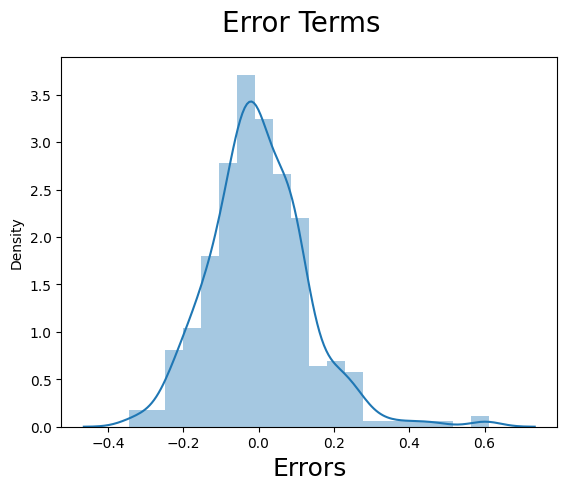

In [102]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train - y_train_price), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)    
plt.show()   
# X-label

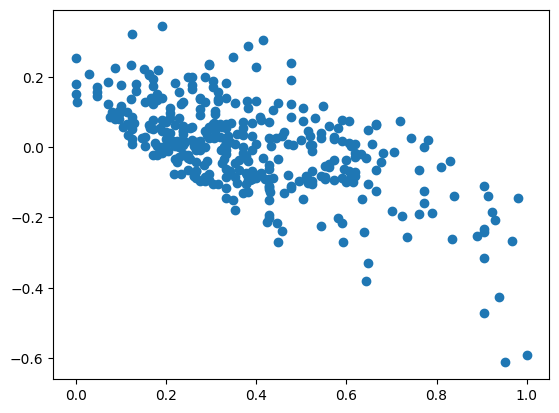

In [103]:
plt.scatter(y_train,res)
plt.show()

## 7. Model Evaluation :

In [104]:
num_vars = ['area','stories', 'bathrooms', 'airconditioning', 'prefarea','parking','price']
df_test[num_vars] = scaler.fit_transform(df_test[num_vars])

### Dividing into X_test and y_test :

In [105]:
y_test = df_test.pop('price')
X_test = df_test

In [106]:
X_test = sm.add_constant(X_test)

In [109]:
# Now let's use our model to make predictions.

# Creating X_test_new dataframe by dropping variables from X_test

x_test_rfe = X_test[x_train_rfe.columns]

In [111]:
# Making predictions

y_pred = lm.predict(x_test_rfe)

In [112]:
from sklearn.metrics import r2_score 
r2_score(y_test, y_pred)

0.5791247774397742

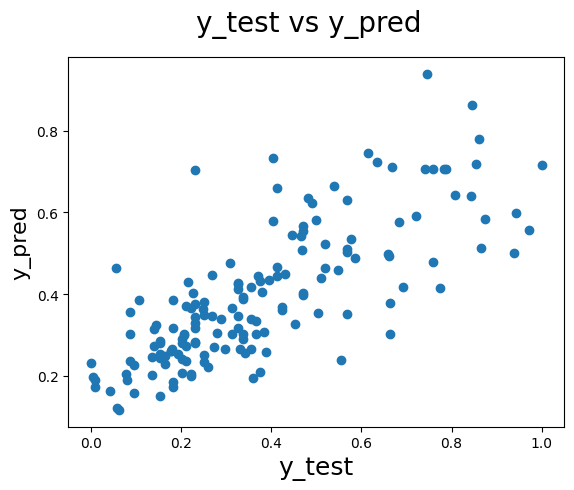

In [114]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16)                          # Y-label
plt.show()

### We can see that the equation of our best fitted line is:

price=0.35×area+0.20×bathrooms+0.19×stories+0.10×airconditioning+0.10×parking+0.11×prefarea